In [1]:
import torchvision
import torchvision.transforms as transforms
import torch
from torchvision import datasets , transforms
from torch.utils.data import DataLoader , Subset
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error,r2_score

# Q1 Basic CNN

Implement a Convolutional Neural Network (CNN) using PyTorch on the fashion
MNIST dataset.
(a) (1)Load the dataset using torchvision.datasets.mnist.FashionMNIST. Use Subset
from torch.utils.data to split into train and test sets.
(b) (2)Build a basic CNN architecture, with 3 convolutional layers and 2 fully con-
nected layers. Each convolutional layer should be followed by a ReLU activation
layer and a max pooling layer.
(c) (2)Train the model on the dataset, and evaluate its performance on the test set.
Plot the accuracy curve.

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])

In [3]:
train_dataset = datasets.mnist.FashionMNIST(root="" , train=True , transform=transform , download=False)

RuntimeError: Dataset not found. You can use download=True to download it

In [ ]:
test_dataset = datasets.mnist.FashionMNIST(root="" , train=False , transform=transform , download=False)

In [5]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, range(20000))
test_subset = Subset(test_dataset, range(5000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)


In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
    
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [7]:
import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")



Epoch 1, Loss: 0.9100
Epoch 2, Loss: 0.5818
Epoch 3, Loss: 0.5087
Epoch 4, Loss: 0.4620
Epoch 5, Loss: 0.4210
Epoch 6, Loss: 0.3920
Epoch 7, Loss: 0.3657
Epoch 8, Loss: 0.3509
Epoch 9, Loss: 0.3309
Epoch 10, Loss: 0.3055


In [8]:
model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")




Test Accuracy: 86.10%


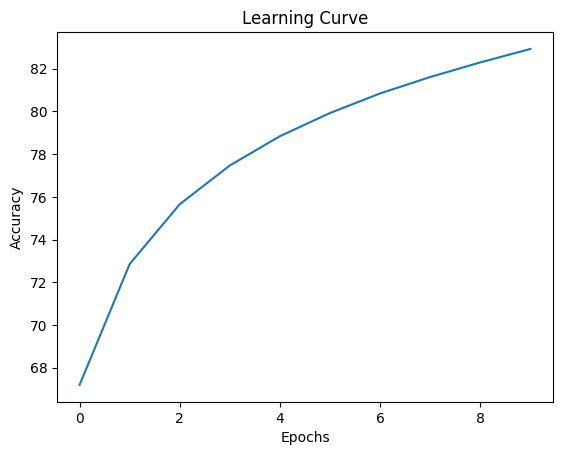

In [9]:
import matplotlib.pyplot as plt


plt.plot(train_accuracy)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.show()


# Q2 Varying the architecture

a) (3)Modify the above architecture to have 2 and 5 convolutional layers respectively,
and train these models. Test these models on the test set and compare their
accuracies.
(b) (3)Using the initial architecture with 3 convolutional layers, introduce dropout
layers to the architecture in two ways:

## A

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))


        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")






Epoch 1, Loss: 0.7218
Epoch 2, Loss: 0.4587
Epoch 3, Loss: 0.3851
Epoch 4, Loss: 0.3474
Epoch 5, Loss: 0.3156
Epoch 6, Loss: 0.2969
Epoch 7, Loss: 0.2702
Epoch 8, Loss: 0.2479
Epoch 9, Loss: 0.2299
Epoch 10, Loss: 0.2100
Test Accuracy: 88.78%


In [13]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3,padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3,padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3,padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = self.relu(self.conv5(x))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")






Epoch 1, Loss: 1.0375
Epoch 2, Loss: 0.5708
Epoch 3, Loss: 0.4423
Epoch 4, Loss: 0.3805
Epoch 5, Loss: 0.3303
Epoch 6, Loss: 0.2995
Epoch 7, Loss: 0.2687
Epoch 8, Loss: 0.2497
Epoch 9, Loss: 0.2296
Epoch 10, Loss: 0.2049
Test Accuracy: 88.86%


Accuracy for model with 5 convolution is greater than model with 2 convolution

## B

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.dropout = nn.Dropout(0.3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(self.relu(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(self.relu(self.conv3(x)))
        x = self.dropout(x)


        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#-----------------------------------------------------------------------------------------------------------------------------------

import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


#-----------------------------------------------------------------------------------------------------------------------------------

model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")






Epoch 1, Loss: 1.1000
Epoch 2, Loss: 0.6857
Epoch 3, Loss: 0.6130
Epoch 4, Loss: 0.5735
Epoch 5, Loss: 0.5404
Epoch 6, Loss: 0.5147
Epoch 7, Loss: 0.4897
Epoch 8, Loss: 0.4721
Epoch 9, Loss: 0.4523
Epoch 10, Loss: 0.4394
Test Accuracy: 84.48%


In [15]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.dropout = nn.Dropout(0.3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))



        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#-----------------------------------------------------------------------------------------------------------------------------------

import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


#-----------------------------------------------------------------------------------------------------------------------------------

model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")






Epoch 1, Loss: 0.9304
Epoch 2, Loss: 0.5969
Epoch 3, Loss: 0.5122
Epoch 4, Loss: 0.4634
Epoch 5, Loss: 0.4245
Epoch 6, Loss: 0.3983
Epoch 7, Loss: 0.3683
Epoch 8, Loss: 0.3538
Epoch 9, Loss: 0.3262
Epoch 10, Loss: 0.3094
Test Accuracy: 86.28%


We got better accuracy on 2nd one which is adding dropout after fully connected layer. This might be due to introducing dropout at convolution removes layer(Not removes but typically data transfer don't happen to next layer) so there might be chance of data loss and getting lower accuracy while adding dropout after connected layer don't turn into lossing of info as that info can be passed through other neurons in next layer as o.7 neurons are still active this was not the case in convolution in convolution data transfer to next layer appen through convolution and if layer is not active no convolution and there won't be any forward data pass to next layer and evantually data loss happens. 

# Q3

In [16]:
import torchvision.models as models

model = models.squeezenet1_1(weights=None)

In [17]:
state_dict = torch.load('squeezenet_weights.pth')

/tmp/ipykernel_15012/1101663077.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('squeezenet_weights.pth')


In [18]:
model.load_state_dict(state_dict)

<All keys matched successfully>

In [20]:
print(model)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

In [21]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,)) , transforms.Lambda(lambda x : x.repeat(3,1,1))])
train_dataset = datasets.mnist.FashionMNIST(root="" , train=True , transform=transform , download=False)
test_dataset = datasets.mnist.FashionMNIST(root="" , train=False , transform=transform , download=False)

In [22]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, range(20000))
test_subset = Subset(test_dataset, range(5000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

correct = 0
total = 0
train_accuracy = []


for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        # images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy.append(100*correct/total)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")



Epoch 1, Loss: 2.6685
Epoch 2, Loss: 1.1529
Epoch 3, Loss: 0.8951
Epoch 4, Loss: 0.7514
Epoch 5, Loss: 0.6655
Epoch 6, Loss: 0.6019
Epoch 7, Loss: 0.5598
Epoch 8, Loss: 0.5121
Epoch 9, Loss: 0.4765
Epoch 10, Loss: 0.4192


In [24]:
model.eval()
correct = 0
total = 0
test_accuracy = []
with torch.no_grad():
    for images, labels in test_loader:
        # images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")




Test Accuracy: 86.02%


CNN is performing better in this case maybe because of it is lighter to train and don't have complex structure so for it it is easier to learn weights and converge perfectly